# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
import random

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

### Task 2: Replace corpus with your own paragraph


In [2]:
raw_text = """
I am really enjoying my time at Celebal. This week, we learned about RNNs,
their architecture, and how they work. We also discussed some of their
drawbacks, such as the vanishing gradient and exploding gradient problems,
which make it difficult for RNNs to learn long-term dependencies effectively.
To overcome these issues, we learned about LSTMs (Long Short-Term Memory
networks). LSTMs maintain two states—the cell state and the hidden
state—which help them retain important information from earlier inputs
while processing sequences. They are much better at handling long-term
dependencies compared to traditional RNNs. We also learned about the
limitations of LSTMs. Their architecture is more complex because they have
a larger number of parameters, which makes them computationally expensive
and increases training time. These limitations are addressed to some extent
by GRUs (Gated Recurrent Units), which have a simpler architecture with
fewer parameters and can train faster while still delivering comparable
performance in many tasks.
"""

cleaned = raw_text.replace("\n", " ").replace("—", " ")
cleaned = " ".join(cleaned.split())

sentences = [s.strip() for s in cleaned.split(".") if s.strip()]
corpus = "\n".join(sentences)

print(f"Sentences: {len(sentences)}")
print(f"Words: {len(cleaned.split())}")
print(corpus)

Sentences: 9
Words: 156
I am really enjoying my time at Celebal
This week, we learned about RNNs, their architecture, and how they work
We also discussed some of their drawbacks, such as the vanishing gradient and exploding gradient problems, which make it difficult for RNNs to learn long-term dependencies effectively
To overcome these issues, we learned about LSTMs (Long Short-Term Memory networks)
LSTMs maintain two states the cell state and the hidden state which help them retain important information from earlier inputs while processing sequences
They are much better at handling long-term dependencies compared to traditional RNNs
We also learned about the limitations of LSTMs
Their architecture is more complex because they have a larger number of parameters, which makes them computationally expensive and increases training time
These limitations are addressed to some extent by GRUs (Gated Recurrent Units), which have a simpler architecture with fewer parameters and can train faster

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

idx = np.arange(len(X))
np.random.shuffle(idx)
split = int(0.85 * len(idx))
train_idx, val_idx = idx[:split], idx[split:]
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]


print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 109
X shape: (150, 31)
y shape: (150,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

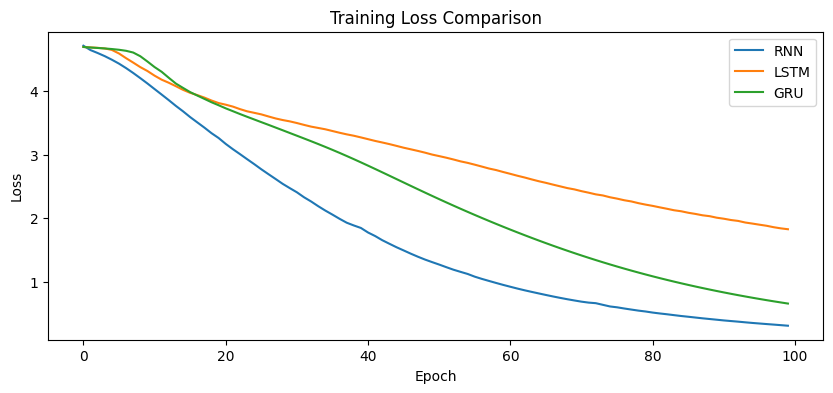

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning also also learned about the
LSTM: deep learning are are addressed to to
GRU : deep learning overcome these issues we learned


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

###  Task 2: Increase Embedding Dimension (32 → 64)

In [10]:
seed = "we learned"
def build_task2_model(rnn_layer):
    model = Sequential([
        Embedding(total_words, 64, input_length=max_len-1),
        rnn_layer,
        Dense(total_words, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

rnn_model_task2 = build_task2_model(SimpleRNN(64))
lstm_model_task2 = build_task2_model(LSTM(64))
gru_model_task2 = build_task2_model(GRU(64))

rnn_history_task2 = rnn_model_task2.fit(X, y, epochs=100, verbose=0)
lstm_history_task2 = lstm_model_task2.fit(X, y, epochs=100, verbose=0)
gru_history_task2 = gru_model_task2.fit(X, y, epochs=100, verbose=0)

print(f"RNN  - baseline loss (embed=32): {rnn_history.history['loss'][-1]:.4f}  | Task 2 loss (embed=64): {rnn_history_task2.history['loss'][-1]:.4f}")
print(f"LSTM - baseline loss (embed=32): {lstm_history.history['loss'][-1]:.4f}  | Task 2 loss (embed=64): {lstm_history_task2.history['loss'][-1]:.4f}")
print(f"GRU  - baseline loss (embed=32): {gru_history.history['loss'][-1]:.4f}  | Task 2 loss (embed=64): {gru_history_task2.history['loss'][-1]:.4f}")
print()
print("RNN  generated:", generate_text(rnn_model_task2, seed, 5))
print("LSTM generated:", generate_text(lstm_model_task2, seed, 5))
print("GRU  generated:", generate_text(gru_model_task2, seed, 5))

RNN  - baseline loss (embed=32): 0.3073  | Task 2 loss (embed=64): 0.1518
LSTM - baseline loss (embed=32): 1.8249  | Task 2 loss (embed=64): 1.3059
GRU  - baseline loss (embed=32): 0.6560  | Task 2 loss (embed=64): 0.3040

RNN  generated: we learned about the of architecture and
LSTM generated: we learned about learned about rnns their
GRU  generated: we learned about the limitations of lstms


Observation:
Increasing the embedding dimension from 32 to 64 allowed the models to learn richer word representations. This helped them capture relationships between words more effectively, resulting in more meaningful and coherent text generation.

### Task 3: Increase Epochs (100 → 200)

In [11]:
seed = "we learned"

def build_task3_model(rnn_layer):
    model = Sequential([
        Embedding(total_words, 32, input_length=max_len-1),
        rnn_layer,
        Dense(total_words, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

rnn_model_task3 = build_task3_model(SimpleRNN(64))
lstm_model_task3 = build_task3_model(LSTM(64))
gru_model_task3 = build_task3_model(GRU(64))

rnn_history_task3 = rnn_model_task3.fit(X, y, epochs=200, verbose=0)
lstm_history_task3 = lstm_model_task3.fit(X, y, epochs=200, verbose=0)
gru_history_task3 = gru_model_task3.fit(X, y, epochs=200, verbose=0)

# loss at the 100-epoch checkpoint should be close to baseline, since training up to that point is identical
print(f"RNN  - baseline @100ep: {rnn_history.history['loss'][-1]:.4f}  | Task 3 @100ep: {rnn_history_task3.history['loss'][99]:.4f}  | Task 3 @200ep: {rnn_history_task3.history['loss'][-1]:.4f}")
print(f"LSTM - baseline @100ep: {lstm_history.history['loss'][-1]:.4f}  | Task 3 @100ep: {lstm_history_task3.history['loss'][99]:.4f}  | Task 3 @200ep: {lstm_history_task3.history['loss'][-1]:.4f}")
print(f"GRU  - baseline @100ep: {gru_history.history['loss'][-1]:.4f}  | Task 3 @100ep: {gru_history_task3.history['loss'][99]:.4f}  | Task 3 @200ep: {gru_history_task3.history['loss'][-1]:.4f}")
print()
print("RNN  generated:", generate_text(rnn_model_task3, seed, 5))
print("LSTM generated:", generate_text(lstm_model_task3, seed, 5))
print("GRU  generated:", generate_text(gru_model_task3, seed, 5))

RNN  - baseline @100ep: 0.3073  | Task 3 @100ep: 0.3114  | Task 3 @200ep: 0.0536
LSTM - baseline @100ep: 1.8249  | Task 3 @100ep: 1.7647  | Task 3 @200ep: 0.6740
GRU  - baseline @100ep: 0.6560  | Task 3 @100ep: 0.6446  | Task 3 @200ep: 0.0931

RNN  generated: we learned about about the limitations of
LSTM generated: we learned about about the of lstms
GRU  generated: we learned learned about the limitations of


Observation:
Training the models for more epochs gave them additional opportunities to learn the underlying patterns in the text corpus. As a result, the models generated more fluent and grammatically consistent text. However, if we increase the number of epochs little too much it may result in overfitting.

### Task 4: Increase Hidden Units (64 → 128)


In [12]:
seed = "we learned"

def build_task4_model(rnn_layer):
    model = Sequential([
        Embedding(total_words, 32, input_length=max_len-1),
        rnn_layer,
        Dense(total_words, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

rnn_model_task4 = build_task4_model(SimpleRNN(128))
lstm_model_task4 = build_task4_model(LSTM(128))
gru_model_task4 = build_task4_model(GRU(128))

rnn_history_task4 = rnn_model_task4.fit(X, y, epochs=100, verbose=0)
lstm_history_task4 = lstm_model_task4.fit(X, y, epochs=100, verbose=0)
gru_history_task4 = gru_model_task4.fit(X, y, epochs=100, verbose=0)

print(f"RNN  - baseline loss (hidden=64): {rnn_history.history['loss'][-1]:.4f}  | Task 4 loss (hidden=128): {rnn_history_task4.history['loss'][-1]:.4f}  | params: {rnn_model.count_params():,} -> {rnn_model_task4.count_params():,}")
print(f"LSTM - baseline loss (hidden=64): {lstm_history.history['loss'][-1]:.4f}  | Task 4 loss (hidden=128): {lstm_history_task4.history['loss'][-1]:.4f}  | params: {lstm_model.count_params():,} -> {lstm_model_task4.count_params():,}")
print(f"GRU  - baseline loss (hidden=64): {gru_history.history['loss'][-1]:.4f}  | Task 4 loss (hidden=128): {gru_history_task4.history['loss'][-1]:.4f}  | params: {gru_model.count_params():,} -> {gru_model_task4.count_params():,}")
print()
print("RNN  generated:", generate_text(rnn_model_task4, seed, 5))
print("LSTM generated:", generate_text(lstm_model_task4, seed, 5))
print("GRU  generated:", generate_text(gru_model_task4, seed, 5))

RNN  - baseline loss (hidden=64): 0.3073  | Task 4 loss (hidden=128): 0.1102  | params: 16,781 -> 38,157
LSTM - baseline loss (hidden=64): 1.8249  | Task 4 loss (hidden=128): 1.1811  | params: 35,405 -> 99,981
GRU  - baseline loss (hidden=64): 0.6560  | Task 4 loss (hidden=128): 0.2248  | params: 29,389 -> 79,757

RNN  generated: we learned about rnns their architecture and
LSTM generated: we learned learned learned about about of
GRU  generated: we learned about the limitations of lstms


Observation:
Increasing the number of hidden units enhanced the learning capacity of the RNN, LSTM, and GRU models.The larger hidden layer enabled the models to retain more information during training, leading to better text generation performance

### Task 5: Generate 10 Words Instead of 5


In [13]:
seed = "we learned"
print("RNN  - 5 words :", generate_text(rnn_model, seed, 5))
print("RNN  - 10 words:", generate_text(rnn_model, seed, 10))
print()
print("LSTM - 5 words :", generate_text(lstm_model, seed, 5))
print("LSTM - 10 words:", generate_text(lstm_model, seed, 10))
print()
print("GRU  - 5 words :", generate_text(gru_model, seed, 5))
print("GRU  - 10 words:", generate_text(gru_model, seed, 10))


RNN  - 5 words : we learned are addressed to some extent
RNN  - 10 words: we learned are addressed to some extent by grus gated recurrent units

LSTM - 5 words : we learned learned about the the lstms
LSTM - 10 words: we learned learned about the the lstms lstms the the the which

GRU  - 5 words : we learned about the limitations of lstms
GRU  - 10 words: we learned about the limitations of lstms long short term memory networks


Observation:
Generating 10 words instead of 5 provided a better way to evaluate how well each model maintains context over longer text sequences.LSTM and GRU produced generally relevant outputs while vanilla RNN was loosing context as sequence size increased due to vanishing gradient Problem.

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**